Found 1239 file(s): ['data_car_0_t17002.csv', 'data_car_1000_t19564.csv', 'data_car_1001_t19567.csv', 'data_car_1002_t19568.csv', 'data_car_1003_t19576.csv', 'data_car_1004_t19586.csv', 'data_car_1005_t19591.csv', 'data_car_1006_t19595.csv', 'data_car_1007_t19596.csv', 'data_car_1008_t19605.csv', 'data_car_1009_t19613.csv', 'data_car_100_t18053.csv', 'data_car_1010_t19626.csv', 'data_car_1011_t19635.csv', 'data_car_1012_t19635.csv', 'data_car_1013_t19646.csv', 'data_car_1014_t19647.csv', 'data_car_1015_t19648.csv', 'data_car_1016_t19651.csv', 'data_car_1017_t19668.csv', 'data_car_1018_t19670.csv', 'data_car_1019_t19673.csv', 'data_car_101_t18053.csv', 'data_car_1020_t19682.csv', 'data_car_1021_t19684.csv', 'data_car_1022_t19685.csv', 'data_car_1023_t19685.csv', 'data_car_1024_t19687.csv', 'data_car_1025_t19689.csv', 'data_car_1026_t19689.csv', 'data_car_1027_t19696.csv', 'data_car_1028_t19700.csv', 'data_car_1029_t19701.csv', 'data_car_102_t18053.csv', 'data_car_1030_t19706.csv', 'data

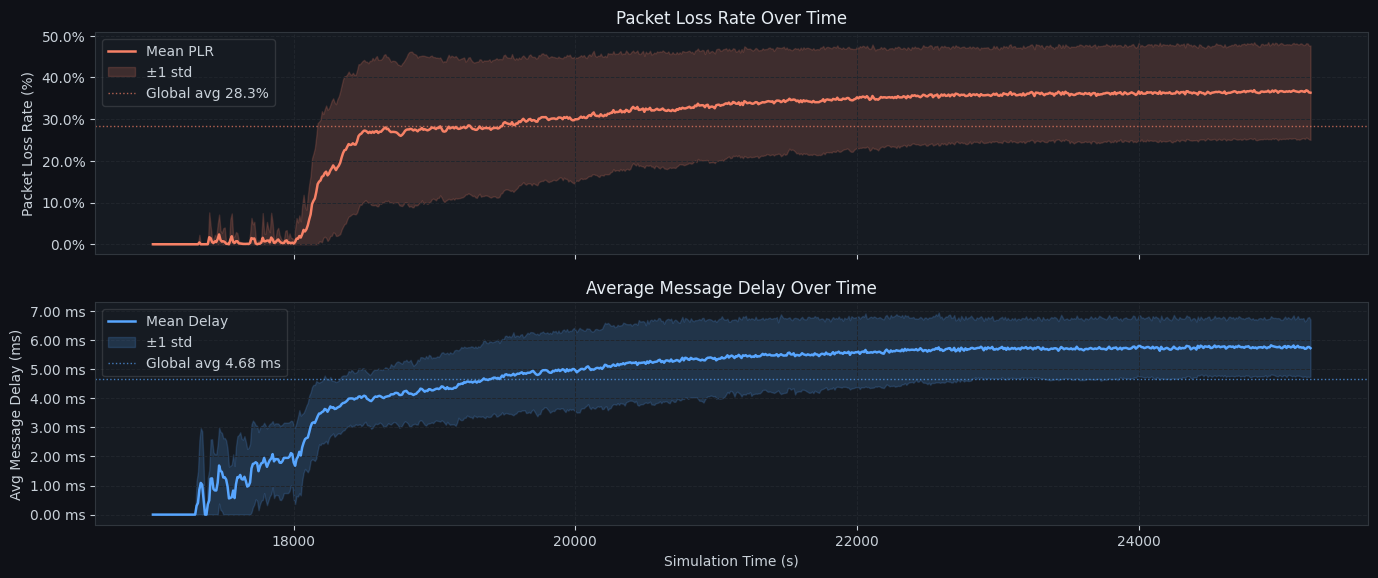


── Global Summary ──────────────────────────────
  Time range       : 17000.0s → 25220.0s
  Vehicles         : 1239
  Total rows       : 35,429,006
  Avg PLR          : 28.32%
  Peak PLR         : 36.96%  @ t=24820.0s
  Avg Delay        : 4.678 ms
  Peak Delay       : 5.820 ms  @ t=24940.0s


In [1]:
import glob
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── CONFIG ────────────────────────────────────────────────────────
DATA_DIR   = "./resources/VANET_data/raw"          # folder containing data_car_*.csv files
PATTERN    = "data_car_*.csv"
BIN_SIZE   = 10.0         # seconds per time bin (increase for smoother curves)
FIGSIZE    = (14, 6)
# ─────────────────────────────────────────────────────────────────

# 1. Load all files
files = sorted(glob.glob(os.path.join(DATA_DIR, PATTERN)))
if not files:
    raise FileNotFoundError(f"No files matching {PATTERN} found in {DATA_DIR}")

print(f"Found {len(files)} file(s)")

dfs = []
for f in files:
    df = pd.read_csv(f, usecols=["Time", "AvgMsgDelay", "PacketLossRate"])
    df["vehicle"] = os.path.basename(f)
    dfs.append(df)

data = pd.concat(dfs, ignore_index=True)
data["AvgMsgDelay_ms"] = data["AvgMsgDelay"] * 1000          # s → ms
data["PLR_pct"]        = data["PacketLossRate"] * 100         # [0,1] → %

# 2. Bin by time
data["TimeBin"] = (data["Time"] // BIN_SIZE) * BIN_SIZE

agg = (
    data
    .groupby("TimeBin")
    .agg(
        PLR_mean   = ("PLR_pct",        "mean"),
        PLR_std    = ("PLR_pct",        "std"),
        Delay_mean = ("AvgMsgDelay_ms", "mean"),
        Delay_std  = ("AvgMsgDelay_ms", "std"),
        n          = ("PLR_pct",        "count"),
    )
    .reset_index()
)

t = agg["TimeBin"].values

# 3. Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=FIGSIZE, sharex=True)
fig.patch.set_facecolor("#0f1117")
for ax in (ax1, ax2):
    ax.set_facecolor("#161b22")
    ax.tick_params(colors="#c9d1d9")
    ax.yaxis.label.set_color("#c9d1d9")
    ax.xaxis.label.set_color("#c9d1d9")
    ax.title.set_color("#e6edf3")
    for spine in ax.spines.values():
        spine.set_edgecolor("#30363d")
    ax.grid(True, color="#21262d", linewidth=0.7, linestyle="--")

# — Panel 1: PLR
ax1.plot(t, agg["PLR_mean"], color="#f78166", linewidth=1.8, label="Mean PLR")
ax1.fill_between(
    t,
    (agg["PLR_mean"] - agg["PLR_std"]).clip(0),
    (agg["PLR_mean"] + agg["PLR_std"]).clip(upper=100),
    color="#f78166", alpha=0.18, label="±1 std"
)
ax1.axhline(agg["PLR_mean"].mean(), color="#f78166", linewidth=1,
            linestyle=":", alpha=0.7, label=f"Global avg {agg['PLR_mean'].mean():.1f}%")
ax1.set_ylabel("Packet Loss Rate (%)")
ax1.set_title("Packet Loss Rate Over Time")
ax1.legend(framealpha=0.15, labelcolor="#c9d1d9", facecolor="#161b22")
ax1.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.1f%%"))

# — Panel 2: Message Delay
ax2.plot(t, agg["Delay_mean"], color="#58a6ff", linewidth=1.8, label="Mean Delay")
ax2.fill_between(
    t,
    (agg["Delay_mean"] - agg["Delay_std"]).clip(0),
    agg["Delay_mean"] + agg["Delay_std"],
    color="#58a6ff", alpha=0.18, label="±1 std"
)
ax2.axhline(agg["Delay_mean"].mean(), color="#58a6ff", linewidth=1,
            linestyle=":", alpha=0.7, label=f"Global avg {agg['Delay_mean'].mean():.2f} ms")
ax2.set_ylabel("Avg Message Delay (ms)")
ax2.set_xlabel("Simulation Time (s)")
ax2.set_title("Average Message Delay Over Time")
ax2.legend(framealpha=0.15, labelcolor="#c9d1d9", facecolor="#161b22")
ax2.yaxis.set_major_formatter(mticker.FormatStrFormatter("%.2f ms"))

plt.tight_layout(pad=1.5)
plt.savefig("plr_delay_over_time.png", dpi=150, bbox_inches="tight",
            facecolor=fig.get_facecolor())
plt.show()

# 4. Summary table
print("\n── Global Summary ──────────────────────────────")
print(f"  Time range       : {t.min():.1f}s → {t.max():.1f}s")
print(f"  Vehicles         : {data['vehicle'].nunique()}")
print(f"  Total rows       : {len(data):,}")
print(f"  Avg PLR          : {agg['PLR_mean'].mean():.2f}%")
print(f"  Peak PLR         : {agg['PLR_mean'].max():.2f}%  @ t={agg.loc[agg['PLR_mean'].idxmax(), 'TimeBin']:.1f}s")
print(f"  Avg Delay        : {agg['Delay_mean'].mean():.3f} ms")
print(f"  Peak Delay       : {agg['Delay_mean'].max():.3f} ms  @ t={agg.loc[agg['Delay_mean'].idxmax(), 'TimeBin']:.1f}s")